In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

In [2]:
rng = np.random.default_rng()
n = 100
# Params for WEAK CORRELATION
# X1 = np.random.normal(loc=10, scale=3, size=n)
# X2 = np.random.normal(loc=5, scale=2, size=n)


# Params for STRONG CORR
X1 = np.random.normal(loc=10, scale=3, size=n)
corr = 0.95
szum_std = 1 - corr
X2 = corr * X1 + np.random.normal(loc=5, scale=szum_std * 3, size=n)

eps = rng.normal(0, 1, n)
beta_0 = 3
beta_1 = 4.4
beta_2 = 3.5
Y = beta_0 + X1 * beta_1 + X2 * beta_2 + eps * 0.2



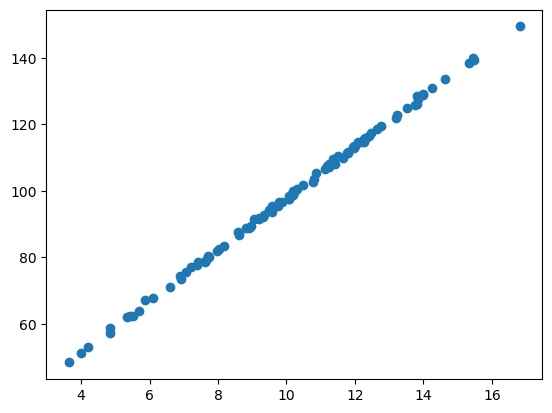

In [3]:
plt.scatter(X1, Y)

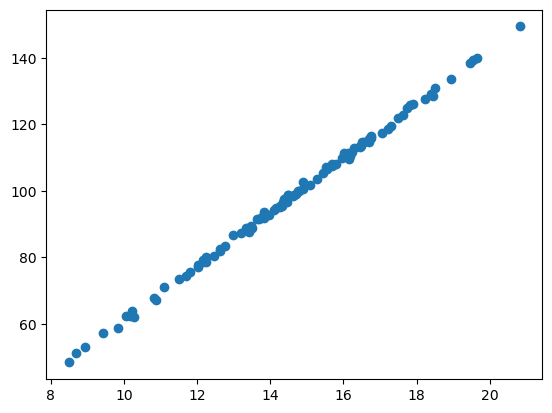

In [4]:
plt.scatter(X2, Y)

In [5]:
df = pd.DataFrame({'Y': Y, 'X1': X1, 'X2': X2})
df.head()

,Y,X1,X2
0,103.616946,10.802050,15.275524
1,88.684343,8.891622,13.344890
2,92.080130,9.325301,13.777425
3,53.044607,4.216354,8.945251
4,131.013699,14.247438,18.508498


In [6]:
def simple_reg(outcome, feature):
    X = sm.add_constant(feature)
    model = sm.OLS(outcome, X).fit()
    
    # Returns [intercept, slope]
    return model.params.iloc[0], model.params.iloc[1]

print(simple_reg(df['Y'], df['X1']))

(np.float64(20.646519370770335), np.float64(7.717468625688253))


In [7]:
beta1 = 15


Y_changed = Y - beta1 * X1
beta_0, beta_2 = simple_reg(Y_changed, df["X1"])
print(beta_0, beta_2)

20.646519370770445 -7.282531374311752


In [8]:
Y_changed2 = Y - beta_2 * X2 

beta0, beta1 = simple_reg(Y_changed2, df["X2"])
print(beta0, beta_1)

-20.11662791347753 4.4



 Final backtracking estimations (after 1000 iter):
  beta0: 1.5421
  beta1: 4.1174
  beta2: 3.7971


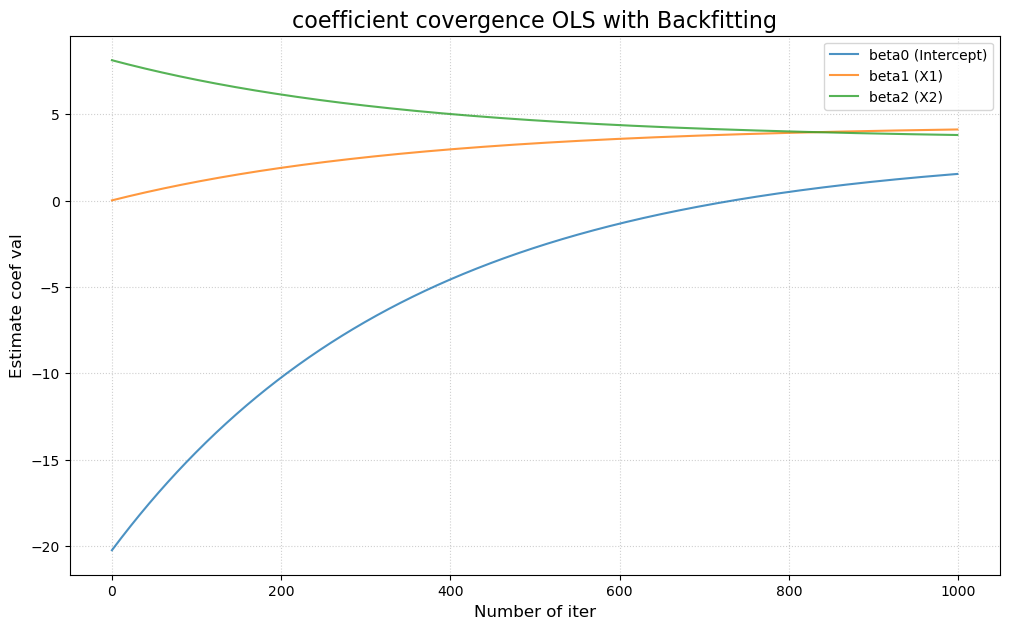

In [9]:
beta1 = 0.0
beta2 = 12.0
beta0 = 0.0

max_iter = 1000

history = {"beta0": [], "beta1": [], "beta2": []}

for i in range(max_iter):
    Y_partial_X2 = Y - beta1 * df["X1"]
    beta0, beta2 = simple_reg(Y_partial_X2, df["X2"])

    Y_partial_X1 = Y - beta2 * df["X2"]
    beta0, beta1 = simple_reg(Y_partial_X1, df["X1"])

    history["beta0"].append(beta0)
    history["beta1"].append(beta1)
    history["beta2"].append(beta2)

print(f"\n Final backtracking estimations (after {max_iter} iter):")
print(f"  beta0: {beta0:.4f}")
print(f"  beta1: {beta1:.4f}")
print(f"  beta2: {beta2:.4f}")

plt.figure(figsize=(12, 7))
plt.plot(history['beta0'], label='beta0 (Intercept)', alpha=0.8)
plt.plot(history['beta1'], label='beta1 (X1)', alpha=0.8)
plt.plot(history['beta2'], label='beta2 (X2)', alpha=0.8)
plt.title('coefficient covergence OLS with Backfitting', fontsize=16)
plt.xlabel('Number of iter', fontsize=12)
plt.ylabel('Estimate coef val', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Estimation comparison: 
  Standard OLS (beta0, beta1, beta2): 2.9189, 4.3768, 3.5234
  Backfitting (beta0, beta1, beta2): 1.5421, 4.1174, 3.7971


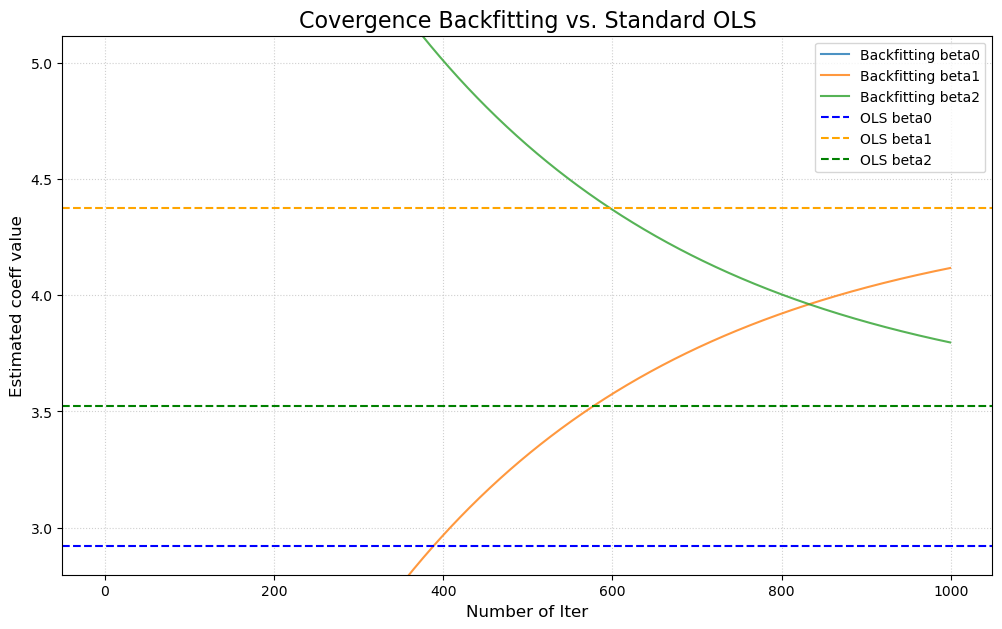

In [10]:
X_multi = df[['X1', 'X2']]
X_multi = sm.add_constant(X_multi)

ols_model = sm.OLS(df['Y'], X_multi).fit()
ols_params = ols_model.params

ols_beta0 = ols_params['const']
ols_beta1 = ols_params['X1']
ols_beta2 = ols_params['X2']

print("Estimation comparison: ")
print(f"  Standard OLS (beta0, beta1, beta2): {ols_beta0:.4f}, {ols_beta1:.4f}, {ols_beta2:.4f}")
print(f"  Backfitting (beta0, beta1, beta2): {beta0:.4f}, {beta1:.4f}, {beta2:.4f}")

plt.figure(figsize=(12, 7))
plt.plot(history['beta0'], label='Backfitting beta0', alpha=0.8)
plt.plot(history['beta1'], label='Backfitting beta1', alpha=0.8)
plt.plot(history['beta2'], label='Backfitting beta2', alpha=0.8)

plt.axhline(y=ols_beta0, color='blue', linestyle='--', label='OLS beta0')
plt.axhline(y=ols_beta1, color='orange', linestyle='--', label='OLS beta1')
plt.axhline(y=ols_beta2, color='green', linestyle='--', label='OLS beta2')

plt.title('Covergence Backfitting vs. Standard OLS', fontsize=16)
plt.xlabel('Number of Iter', fontsize=12)
plt.ylabel('Estimated coeff value', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(min(history['beta2']) - 1, max(history['beta1']) + 1)
plt.show()

In [11]:
tolerance = 0.1
converged_iter = max_iter

for i in range(max_iter):
    diff0 = abs(history['beta0'][i] - ols_beta0)
    diff1 = abs(history['beta1'][i] - ols_beta1)
    diff2 = abs(history['beta2'][i] - ols_beta2)
    
    if diff0 < tolerance and diff1 < tolerance and diff2 < tolerance:
        converged_iter = i + 1
        break

print("\n(h) Covergence analysis:")
print(f"Tolerance: {tolerance}")
print(f"Minimal number of iteration required to achieve tolerance: {converged_iter}")


(h) Covergence analysis:
Tolerance: 0.1
Minimal number of iteration required to achieve tolerance: 1000


## ---- SUMMARY -- 
### Backtracking method works well when predictors are independent from each other. It quickly leads to convergence and finding right coefficients. However when predictors are dependent, this method has not good performance. It is better to use OLS.